In [1]:
import numpy as np
import scipy.stats

from matplotlib import pyplot as plt

First generate some example data.

In [67]:
NUM_SAMPLES = 50000
# standard normal underlying distribution
rng = np.random.default_rng(seed=1234)
true_locations = rng.standard_normal(size=NUM_SAMPLES)

# and create our discretized normal distribution representing
# the model output (for now, assume the model assigns the same
# distribution for every input)
bins = np.linspace(-5, 5, 1000)
model_output = scipy.stats.norm().pdf(bins)
# normalize so it sums to 1
model_output /= model_output.sum()

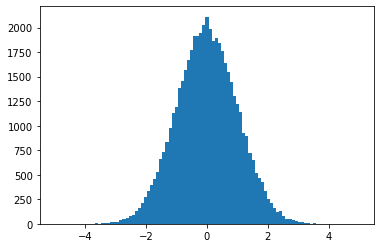

In [69]:
plt.rcParams['figure.facecolor'] = 'white'
plt.hist(true_locations, bins=np.linspace(-5, 5, 100))
plt.show()

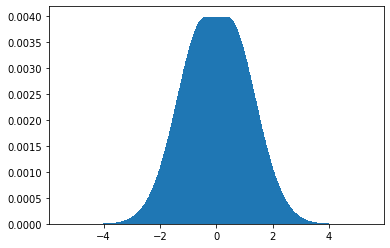

In [70]:
plt.bar(bins, model_output)
plt.show()

Now define our calibration function.

In [72]:
def assign_to_bin_1d(true_y, bins):
    x_0 = bins[0]
    dx = bins[1] - x_0
    i = int((true_y - x_0) / dx)
    return i

In [79]:
def f(p_i: np.ndarray, loc: float, bins):
    bin_idx = assign_to_bin_1d(loc, bins)
    indices = p_i.argsort()[::-1]
    k = (indices == bin_idx).argmax()
    return p_i[indices[:k]].sum()

In [73]:
bins[1] - bins[0]

0.010010010010010006

In [74]:
assign_to_bin_1d(0, bins)

499

In [81]:
f(model_output, true_locations[0], bins)

0.8907582406915655

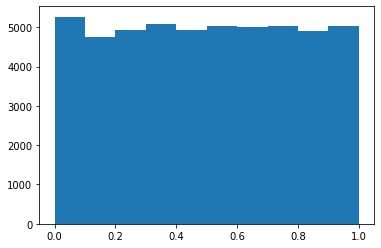

In [82]:
s = []
for y_i in true_locations:
    s_i = f(model_output, y_i, bins)
    s.append(s_i)
plt.hist(s)
plt.show()

In [135]:
def f_vectorized(maps: np.ndarray, locations: np.ndarray):
    # maps: (n_samples, n_bins)
    # locations: (n_samples,)
    # argsort each row in descending order
    idx_matrix = maps.argsort(axis=1)[:, ::-1]
    # integer representing which bin each location is contained in
    loc_idxs = np.array([assign_to_bin_1d(loc, bins) for loc in locations])
    # integers storing first bin at which associated interval contains
    # the true location y
    # print(idx_matrix.shape)
    # print(loc_idxs.shape)
    bin_idxs = (idx_matrix == loc_idxs[:, np.newaxis]).argmax(axis=1)
    # distribution with values at indices above bin_idxs zeroed out
    # x_idx = [
    # [0, 1, 2, 3, ...],
    # [0, 1, 2, 3, ...]
    # ]
    x_idx = np.arange(len(bins))[np.newaxis, :].repeat(NUM_SAMPLES, axis=0)
    condition = x_idx > bin_idxs[:, np.newaxis]
    maps.sort(axis=1)
    s = np.where(condition, 0, maps[:, ::-1]).sum(axis=1)
    return s

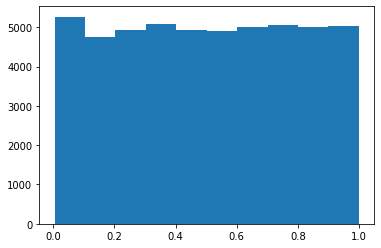

In [136]:
# (N_BINS,) --> (1, N_BINS) --> (NUM_SAMPLES, N_BINS)
maps = model_output[np.newaxis, :].repeat(NUM_SAMPLES, axis=0)
plt.hist(f_vectorized(maps, true_locations))
plt.show()

2d time

In [138]:
rng = np.random.default_rng(seed=2022)
cov = np.array([[1, 0], [0, 1]])
locations_2d = rng.multivariate_normal([0, 0], cov, size=NUM_SAMPLES)

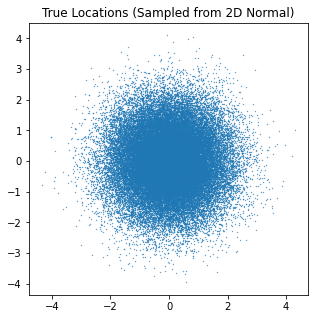

In [175]:
plt.figure(figsize=(5,5))
plt.scatter(locations_2d[:, 0], locations_2d[:, 1], s=0.1)
plt.title('True Locations (Sampled from 2D Normal)')
plt.show()

In [147]:
min_x, min_y = locations_2d.min(axis=0) - 1
max_x, max_y = locations_2d.max(axis=0) + 1

In [176]:
x_coords = np.linspace(min_x, max_x, 100)
y_coords = np.linspace(min_y, max_y, 100)

xgrid, ygrid = np.meshgrid(x_coords, y_coords)

coord_matrix = np.dstack([xgrid, ygrid])
output_2d = scipy.stats.multivariate_normal([0, 0], cov).pdf(coord_matrix)
output_2d /= output_2d.sum() # normalize to sum 1

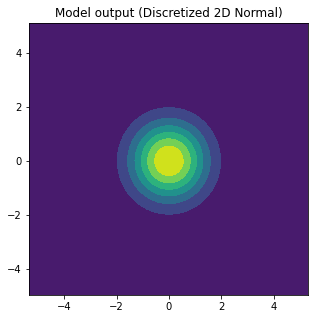

In [178]:
plt.figure(figsize=(5,5))
plt.contourf(xgrid, ygrid, output_2d)
plt.title('Model output (Discretized 2D Normal)')
plt.show()

In [223]:
def assign_to_bin_2d(locations, bins):
    # locations: (NUM_SAMPLES, 2)
    # bins: (n_y_pts, n_x_pts, 2)
    x_coords = locations[:, 0]
    y_coords = locations[:, 1]
    # 1d array of numbers representing x coord of each bin
    x_bins = bins[0, :, 0]
    # same for y coord
    y_bins = bins[:, 0, 1]
    x_idxs = [assign_to_bin_1d(x_coord, x_bins) for x_coord in x_coords]
    y_idxs = [assign_to_bin_1d(y_coord, y_bins) for y_coord in y_coords]
    # NOTE: we expect model output to have shape (NUM_SAMPLES, n_x_pts, n_y_pts)
    # so when we flatten, the entry at coordinate (i, j) gets mapped to
    # i * n_y_pts + j
    n_y_pts = bins.shape[0]
    # print(list(zip(x_idxs, y_idxs)))
    return np.array([i * n_y_pts + j for i, j in zip(x_idxs, y_idxs)])

In [224]:
assign_to_bin_2d(np.array([[0, 0], [1,1]]), coord_matrix)

array([4948, 5858])

In [227]:
reversed_coord_matrix = np.swapaxes(coord_matrix, 0, 1)
flattened = reversed_coord_matrix.reshape((-1, 2))
flattened[4948], flattened[5049]

(array([-0.07310327, -0.07952709]), array([0.0346595 , 0.02203417]))

In [232]:
def f_2d(maps: np.ndarray, locations: np.ndarray, coord_bins: np.ndarray):
    # maps: (NUM_SAMPLES, n_x_pts, n_y_pts)
    # locations: (NUM_SAMPLES, 2)
    # coord_bins: (n_y_pts, n_x_pts, 2)  ( output of meshgrid then dstack )
    # reshape maps to (NUM_SAMPLES, N_BINS)
    flattened_maps = maps.reshape((NUM_SAMPLES, -1))
    idx_matrix = flattened_maps.argsort(axis=1)[:, ::-1]
    # bin number for each location
    loc_idxs = assign_to_bin_2d(locations, coord_bins)
    # bin number for first interval containing location
    bin_idxs = (idx_matrix == loc_idxs[:, np.newaxis]).argmax(axis=1)
    # distribution with values at indices above bin_idxs zeroed out
    # x_idx = [
    # [0, 1, 2, 3, ...],
    # [0, 1, 2, 3, ...]
    # ]
    num_bins = coord_bins.shape[0] * coord_bins.shape[1]
    x_idx = np.arange(num_bins)[np.newaxis, :].repeat(NUM_SAMPLES, axis=0)
    condition = x_idx > bin_idxs[:, np.newaxis]
    flattened_maps.sort(axis=1)
    s = np.where(condition, 0, flattened_maps[:, ::-1]).sum(axis=1)
    return s

In [234]:
maps = output_2d[np.newaxis, :].repeat(NUM_SAMPLES, axis=0)
s = f_2d(maps, locations_2d, coord_matrix)

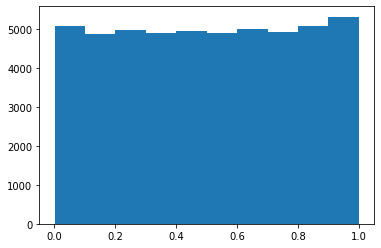

In [235]:
plt.hist(s)
plt.show()

sweet!

In [181]:
fake_data = np.arange(24).reshape((2, 4, 3))
fake_data

array([[[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]],

       [[12, 13, 14],
        [15, 16, 17],
        [18, 19, 20],
        [21, 22, 23]]])

In [182]:
fake_data.reshape((2, -1))

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]])

In [106]:
maps = model_output[np.newaxis, :].repeat(NUM_SAMPLES, axis=0)

In [107]:
maps.argsort(axis=1)

array([[  0, 999, 998, ..., 501, 500, 499],
       [  0, 999, 998, ..., 501, 500, 499],
       [  0, 999, 998, ..., 501, 500, 499],
       ...,
       [  0, 999, 998, ..., 501, 500, 499],
       [  0, 999, 998, ..., 501, 500, 499],
       [  0, 999, 998, ..., 501, 500, 499]])

In [99]:
rng = np.random.default_rng(seed=1000)
arr = rng.random(12).reshape((4, 3)) * 5
arr.sort(axis=1)
print(arr[:, ::-1])

[[3.01920924 2.60692869 2.35470899]
 [2.64379513 1.01623971 0.9551814 ]
 [3.76840776 2.75835888 1.40772799]
 [4.31861038 4.0268611  1.24186332]]
